# **Data Modelling and Evaluating**
---

## Objectives

* Validate hypothesis 3: 
    * Training the model without image augmentation reduces the accuracy and increases the losses.
* Answer part of **Business Requirement 2**: identifying animal species in images, while showing the effect of augmentation.


## Inputs

* Training dataset: inputs/datasets/animals/image/train/  
* Validation dataset: inputs/datasets/animals/image/validation/
* Test dataset: inputs/datasets/animals/image/test/
* Class indices mapping (`outputs/v1/class_indices.pkl`) 

## Outputs

* Model trained without augmentation. 
* Images distribution plot in train, validation, and test set.
* Class indices mapping.
* Machine learning model creation and training.
* Saved trained model.
* Learning curve plots for model performance.
* Model evaluation stored in pickle file.
* Prediction on a random image file.


## Additional Comments | Insights | Conclusions

* Running without augmentation provides a baseline performance.

---

## Import Packages

In [1]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from matplotlib.image import imread
sns.set_style("white")

2025-09-28 22:12:56.355443: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-28 22:12:56.370600: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-28 22:12:58.023049: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-28 22:13:01.240745: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

## Set Seeds

In [2]:
os.environ["PYTHONHASHSEED"] = "0"
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

## Set Working Directory

In [3]:
cwd = os.getcwd()
os.chdir('/workspaces/Animal_detection_camera')
print("You set a new current directory")

work_dir = os.getcwd()
work_dir

You set a new current directory


'/workspaces/Animal_detection_camera'

## Set input directories
Set train, validation and test paths

In [4]:
my_data_dir = 'inputs/datasets/animals/image'
train_path = my_data_dir + '/train'
val_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'


## Set output directory

In [5]:
version = 'v1'
file_path = f'outputs/{version}/no_aug'
os.makedirs(file_path, exist_ok=True)
img_path = f'app_images/no_aug'
os.makedirs(img_path, exist_ok=True)

if 'outputs' in os.listdir(work_dir) and version in os.listdir(work_dir + '/outputs'):
    print('Old version is already available, create a new version.')
else:
    os.makedirs(name=file_path, exist_ok=True)

Old version is already available, create a new version.


## Set labels

In [6]:
labels = os.listdir(train_path)

print(
    f"Project Labels: {labels}"
)

Project Labels: ['lemur', 'snake', 'elephant', 'frog', 'chimpanzee', 'chinchilla', 'flamingo', 'mongoose', 'ostrich', 'ferret', 'camel', 'bee', 'mole', 'penguin', 'leopard', 'hawk', 'hedgehog', 'walrus', 'falcon', 'grasshopper', 'beaver', 'antelope', 'giraffe', 'duck', 'lizard', 'crab', 'goose', 'gorilla', 'jaguar', 'sheep', 'lynx', 'butterfly', 'panda', 'goat', 'deer', 'peacock', 'dog', 'whale', 'kangaroo', 'seal', 'cheetah', 'cow', 'iguana', 'hippopotamus', 'fox', 'cat', 'donkey', 'raccoon', 'blackbird', 'buffalo', 'koala', 'crocodile', 'dolphin', 'hyena', 'porcupine', 'bear', 'squid', 'spider', 'eagle', 'bison', 'owl', 'otter', 'snail', 'wolf']


## Set Image Shape

In [7]:
image_shape = joblib.load(filename=f"outputs/{version}/image_shape.pkl")
image_shape = (128, 128, 3)
print("Using image shape:", image_shape)

Using image shape: (128, 128, 3)


---

# Number of images in train, test and validation data
---

* train - lemur: 151 images
* train - snake: 151 images
* train - elephant: 201 images
* train - frog: 218 images
* train - chimpanzee: 151 images
* train - chinchilla: 151 images
* train - flamingo: 151 images
* train - mongoose: 151 images
* train - ostrich: 151 images
* train - ferret: 151 images
* train - camel: 151 images
* train - bee: 151 images
* train - mole: 123 images
* train - penguin: 151 images
* train - leopard: 151 images
* train - hawk: 151 images
* train - hedgehog: 151 images
* train - walrus: 151 images
* train - falcon: 151 images
* train - grasshopper: 151 images
* train - beaver: 151 images
* train - antelope: 151 images
* train - giraffe: 151 images
* train - duck: 151 images
* train - lizard: 151 images
* train - crab: 151 images
* train - goose: 151 images
* train - gorilla: 151 images
* train - jaguar: 130 images
* train - sheep: 151 images
* train - lynx: 151 images
* train - butterfly: 151 images
* train - panda: 151 images
* train - goat: 151 images
* trai

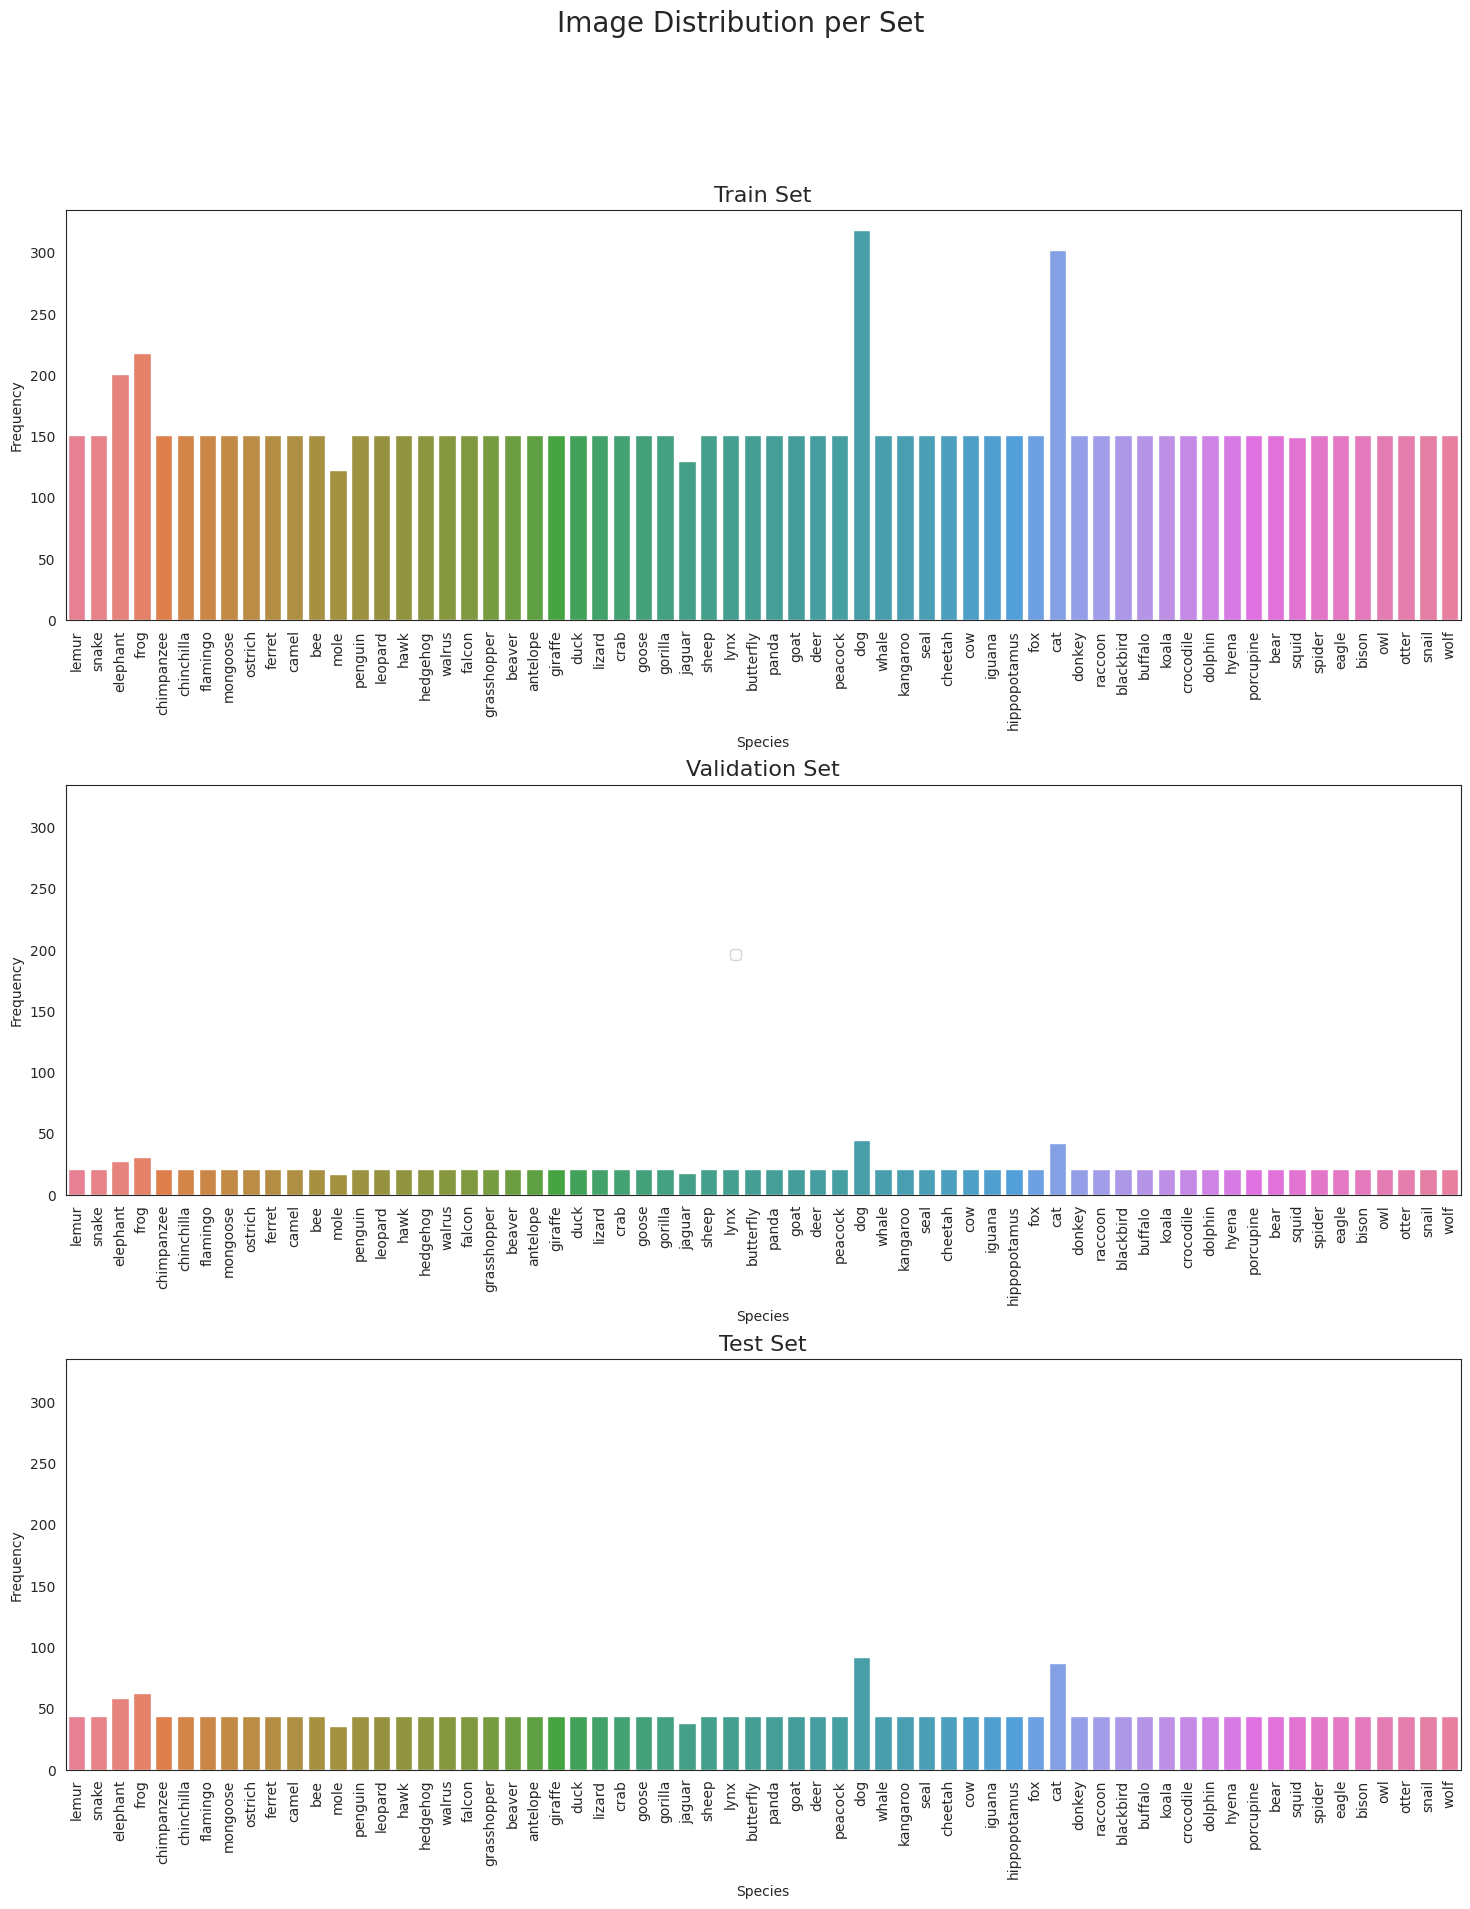

In [8]:
data = {'Set': [], 'Label': [], 'Frequency': []}
folders = ['train', 'validation', 'test']

for folder in folders:
    for label in labels:
        n = len(os.listdir(my_data_dir + '/' + folder + '/' + label))
        data['Set'].append(folder)
        data['Label'].append(label)
        data['Frequency'].append(n)
        print(f"* {folder} - {label}: {n} images")

df_freq = pd.DataFrame(data)

fig, axes = plt.subplots(3, 1, figsize=(18, 20), sharey=True)

sets = ['train', 'validation', 'test']

for i, subset in enumerate(sets):
    sns.barplot(
        data=df_freq[df_freq['Set'] == subset],
        x='Label', y='Frequency', hue='Label', dodge=False, ax=axes[i]
    )
    axes[i].set_title(f"{subset.capitalize()} Set", fontsize=16)
    axes[i].set_xlabel("Species")
    axes[i].set_ylabel("Frequency")
    axes[i].tick_params(axis='x', rotation=90)

handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='center', ncol=6, fontsize=10)

plt.subplots_adjust(hspace=0.4, bottom=0.1)

fig.suptitle("Image Distribution per Set", fontsize=20)
plt.savefig(f'{img_path}/labels_distribution_rows.jpg', dpi=150, bbox_inches='tight')
plt.show()


---

# Data Generators (No Augmentation)
---

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 16
datagen = ImageDataGenerator(rescale=1./255)

### Training set

In [10]:
train_set = datagen.flow_from_directory(
    train_path,
    target_size=image_shape[:2],
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

Found 10050 images belonging to 64 classes.


### Validation set

In [11]:
validation_set = datagen.flow_from_directory(
    val_path,
    target_size=image_shape[:2],
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1400 images belonging to 64 classes.


### Test set

In [12]:
test_set = datagen.flow_from_directory(
    test_path,
    target_size=image_shape[:2],
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2927 images belonging to 64 classes.


Save class indices mapping

In [13]:
joblib.dump(value=train_set.class_indices,
            filename=f"{file_path}/class_indices_no_aug.pkl")

['outputs/v1/no_aug/class_indices_no_aug.pkl']

---

# Model creation
---

## ML model

Import model packages

In [14]:
from keras.applications import MobileNetV2
from keras.models import Model
from keras.layers import Dense, Dropout, GlobalAveragePooling2D

### Model

In [15]:
def create_tf_model():
    # Load pretrained base model
    base_model = MobileNetV2(
        input_shape=image_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze base layers
    base_model.trainable = False

    # Add custom classification layers on top
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(len(labels), activation='softmax')(x)

    # Build the model
    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


### Model Summary

In [16]:
create_tf_model().summary()

2025-09-28 22:13:07.379153: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,602,368 (9.93 MB)

 Trainable params: 344,384 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Early Stopping 

In [17]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

ckpt = ModelCheckpoint(
    filepath=f"{file_path}/model_epoch{{epoch:02d}}-val_acc{{val_accuracy:.2f}}.weights.h5",
    save_weights_only=True,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

## Fit model for model training

In [18]:
model = create_tf_model()
history = model.fit(
    train_set,
    epochs=25,
    validation_data=validation_set,
    callbacks=[early_stop, reduce_lr, ckpt],
    verbose=1
)


/home/cistudent/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.7319 - loss: 1.1668
Epoch 1: val_accuracy improved from None to 0.97357, saving model to outputs/v1/no_aug/model_epoch01-val_acc0.97.weights.h5
629/629 ━━━━━━━━━━━━━━━━━━━━ 206s 321ms/step - accuracy: 0.8783 - loss: 0.4858 - val_accuracy: 0.9736 - val_loss: 0.0847 - learning_rate: 0.0010
Epoch 2/25
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9663 - loss: 0.0968
Epoch 2: val_accuracy improved from 0.97357 to 0.97429, saving model to outputs/v1/no_aug/model_epoch02-val_acc0.97.weights.h5
629/629 ━━━━━━━━━━━━━━━━━━━━ 201s 319ms/step - accuracy: 0.9690 - loss: 0.0921 - val_accuracy: 0.9743 - val_loss: 0.0684 - learning_rate: 0.0010
Epoch 3/25
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9705 - loss: 0.0820
Epoch 3: val_accuracy improved from 0.97429 to 0.98500, saving model to outputs/v1/no_aug/model_epoch03-val_acc0.99.weights.h5
629/629 ━━━━━━━━━━━━━━━━━━━━ 201s 320ms/step - accuracy: 0.9767 - lo

## Save Model

In [19]:
model.save(f"{file_path}/final_model_no_aug.keras")
model.save_weights(f"{file_path}/animal_detector_model_no_aug.weights.h5")

---

# Model Performance
---

## Model Learning Curve

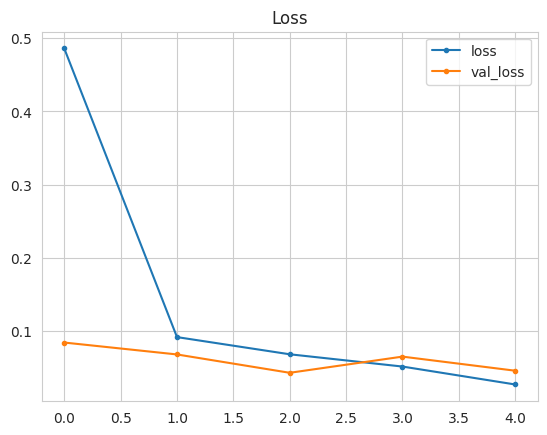

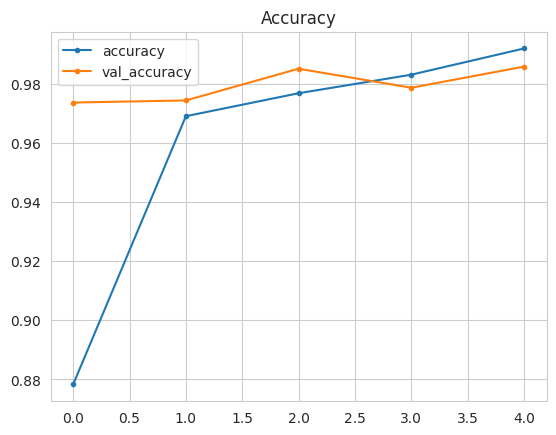

In [20]:
losses = pd.DataFrame(history.history)

sns.set_style("whitegrid")
losses[['loss', 'val_loss']].plot(style='.-')
plt.title("Loss")
plt.savefig(f'{img_path}/model_training_losses.jpg',
    bbox_inches='tight', dpi=150)
plt.show()

print("\n")
losses[['accuracy', 'val_accuracy']].plot(style='.-')
plt.title("Accuracy")
plt.savefig(f'{img_path}/model_training_acc.jpg',
    bbox_inches='tight', dpi=150)
plt.show()

## Model Evaluation

Load saved model

In [21]:
from tensorflow.keras.models import load_model
model = create_tf_model()
model.load_weights(f"{file_path}/animal_detector_model_no_aug.weights.h5")

/home/cistudent/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Evaluate model on test set

In [22]:
evaluation = model.evaluate(test_set)

/home/cistudent/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


183/183 ━━━━━━━━━━━━━━━━━━━━ 49s 255ms/step - accuracy: 0.9874 - loss: 0.0344


### Save evaluation pickle

In [23]:
joblib.dump(value=evaluation,
    filename=f"{file_path}/evaluation_no_aug.pkl"
    )
print("Test Evaluation:", evaluation)

Test Evaluation: [0.034407541155815125, 0.9873590469360352]


# Evaluate Test Set

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


test_loss, test_acc = model.evaluate(test_set, verbose=1)
print(f"\n Test Accuracy: {test_acc:.4f}")
print(f" Test Loss: {test_loss:.4f}")

183/183 ━━━━━━━━━━━━━━━━━━━━ 49s 268ms/step - accuracy: 0.9874 - loss: 0.0344

 Test Accuracy: 0.9874
 Test Loss: 0.0344


### Load true labels

In [25]:
y_true = test_set.classes

Get predicted probablities for test set images

In [26]:
y_pred_probs = model.predict(test_set, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

183/183 ━━━━━━━━━━━━━━━━━━━━ 51s 274ms/step


Map indices back to labels and print classification report

In [27]:
target_names = list(train_set.class_indices.keys())

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names))


--- Classification Report ---
              precision    recall  f1-score   support

    antelope       1.00      1.00      1.00        44
        bear       1.00      0.95      0.98        44
      beaver       1.00      1.00      1.00        44
         bee       1.00      1.00      1.00        44
       bison       0.98      0.93      0.95        44
   blackbird       1.00      1.00      1.00        44
     buffalo       0.94      1.00      0.97        44
   butterfly       1.00      1.00      1.00        44
       camel       1.00      0.98      0.99        44
         cat       1.00      0.98      0.99        87
     cheetah       1.00      1.00      1.00        44
  chimpanzee       1.00      1.00      1.00        44
  chinchilla       0.98      1.00      0.99        44
         cow       1.00      1.00      1.00        44
        crab       1.00      1.00      1.00        44
   crocodile       1.00      0.95      0.98        44
        deer       1.00      1.00      1.00       

### Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix - Animal Species Classification')

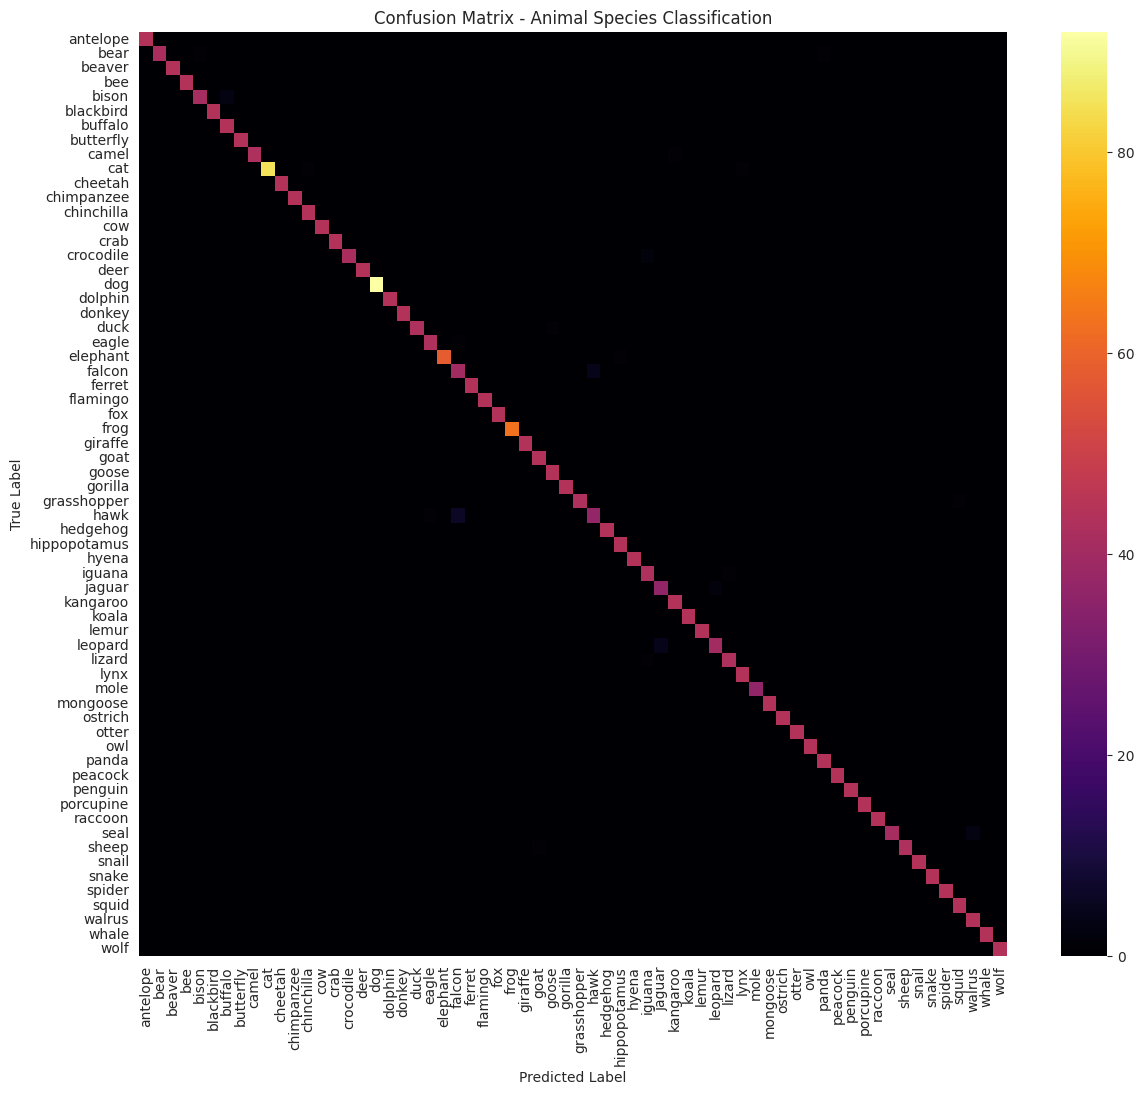

In [28]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="inferno", 
            xticklabels=target_names, 
            yticklabels=target_names, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix - Animal Species Classification")

Save confusion matrix

In [29]:
save_dir = "outputs/v1"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(img_path, "confusion_matrix_no_aug.jpg")
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Confusion matrix saved to {save_path}")

Confusion matrix saved to app_images/no_aug/confusion_matrix_no_aug.jpg


In [30]:
plt.show()

## Predict on new data

Load a random image as PIL

Selected species: bison
Image shape: (128, 128), Image mode: RGB


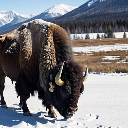

In [31]:
from tensorflow.keras.preprocessing import image
import random

# Pick a random label (species)
label = random.choice(labels)

# Pick a random image index from that label's folder
pointer = random.randint(0, len(os.listdir(test_path + '/' + label)) - 1)

# Load the image
pil_image = image.load_img(
    test_path + '/' + label + '/' + os.listdir(test_path + '/' + label)[pointer],
    target_size=image_shape[:2],
    color_mode='rgb'
)

print(f"Selected species: {label}")
print(f"Image shape: {pil_image.size}, Image mode: {pil_image.mode}")
pil_image


Convert image to array and prepare for prediction

In [32]:
my_image = image.img_to_array(pil_image)
my_image = np.expand_dims(my_image, axis=0)/255
print(my_image.shape)
print("Image batch shape:", my_image.shape)
print("True label:", label)


(1, 128, 128, 3)
Image batch shape: (1, 128, 128, 3)
True label: bison


Predict class probabilities

In [33]:
# Get prediction probabilities for all classes
pred_probs = model.predict(my_image)[0]

target_map = {v: k for k, v in train_set.class_indices.items()}

pred_class_index = np.argmax(pred_probs)
pred_class = target_map[pred_class_index]

print("True label:", label)
print("Predicted label:", pred_class)
print("Prediction confidence:", pred_probs[pred_class_index])

# Show top 3 predictions and their probabilities
top_3 = np.argsort(pred_probs)[-3:][::-1]
print("\nTop 3 predictions:")
for i in top_3:
    print(f"{target_map[i]}: {pred_probs[i]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
True label: bison
Predicted label: bison
Prediction confidence: 0.9534394

Top 3 predictions:
bison: 0.9534
buffalo: 0.0465
eagle: 0.0000


In [34]:
import pandas as pd

results_df = pd.DataFrame({
    "filepath": test_set.filepaths,
    "true_label": [target_names[i] for i in y_true],
    "predicted_label": [target_names[i] for i in y_pred]
})

results_df.to_csv("inputs/datasets/animal_predictions.csv", index=False)

results_df["image"] = test_set.filenames
